In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/e-commerce-sales-data/ecommerce_sales_data.csv


In [2]:
df=pd.read_csv('/kaggle/input/e-commerce-sales-data/ecommerce_sales_data.csv')

In [3]:
df.head(5) #check the first first five rows of the dataset

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [4]:
df.info() # Check the data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [5]:
df.isnull().sum() # check the null values of the dataset

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [6]:
df.describe() # Check the statistical summary of the dataset

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [7]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values(by='Profit', ascending=False) # Group the DataFrame 'df' by the 'Category' column, summing up 'Sales' and 'Profit' for each category.
print("Category Summary:\n")
print(category_summary.reset_index()) #Display the plot

Category Summary:

      Category    Sales     Profit
0  Electronics  5326074  923185.59
1  Accessories  4247591  736084.74
2       Office  1094216  185394.88


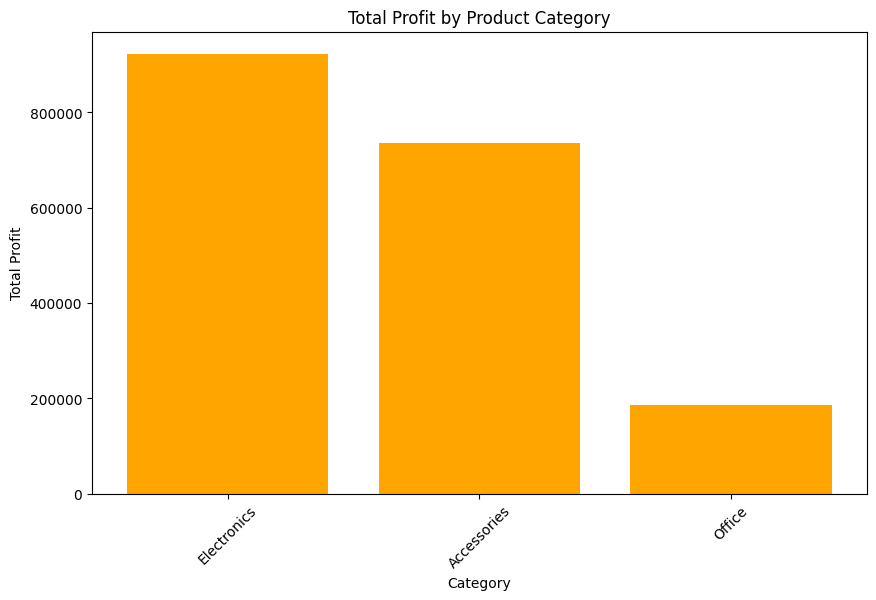

In [8]:
# Reset index if 'Category' is the index
category_summary_plot = category_summary.reset_index()

# Set figure size
plt.figure(figsize=(10,6))

# Create a bar chart
plt.bar(category_summary_plot['Category'], category_summary_plot['Profit'], color='orange')

# Add title and axis labels
plt.title('Total Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

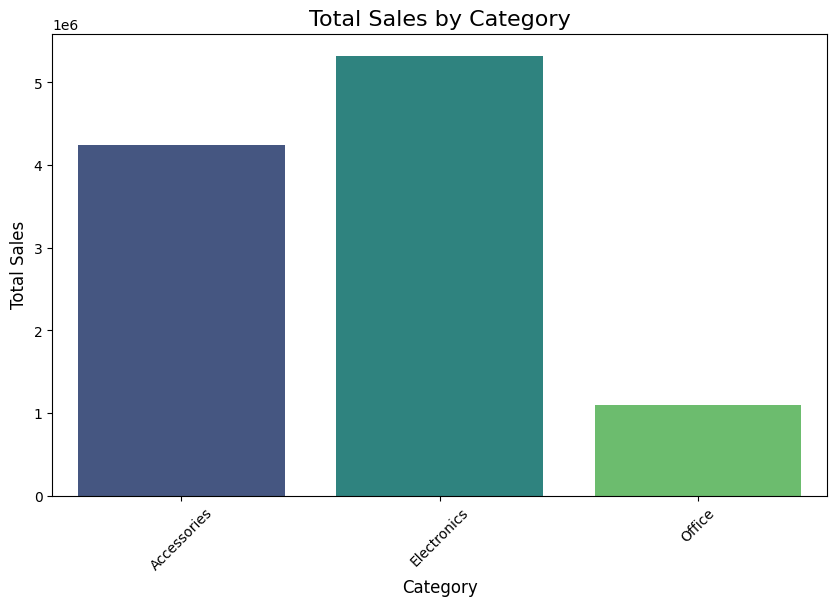

In [9]:
Sales_Most_Category=df.groupby('Category')['Sales'].sum() # Calculate the sum of profit for each category
plt.figure(figsize=(10,6)) #Set the size of the plot
sns.barplot(x=Sales_Most_Category.index, y=Sales_Most_Category.values, palette="viridis") #create a barplot
plt.title("Total Sales by Category", fontsize=16) #set the title of the plot
plt.xlabel("Category", fontsize=12) # x-axis of the plot
plt.ylabel("Total Sales", fontsize=12) #y-axis of the plot
plt.xticks(rotation=45)
plt.show()

In [10]:
Most_Profitable_Region=df.groupby('Region')['Profit'].sum().sort_values(ascending=False) #Calculate the profit for each Region
print("Most Profitable Region:\n")
print(Most_Profitable_Region.to_frame().reset_index()) #Disply most profitable region

Most Profitable Region:

  Region     Profit
0   West  495358.73
1   East  464888.46
2  South  458103.27
3  North  426314.75


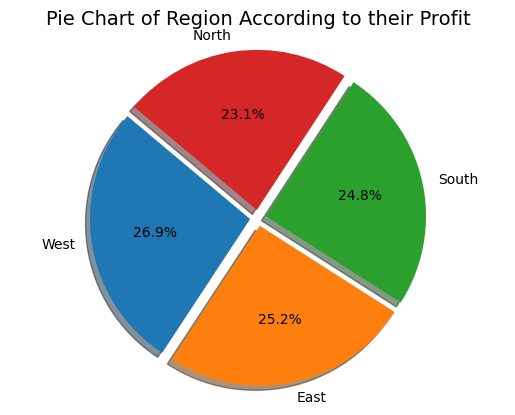

In [11]:
plt.pie(
    Most_Profitable_Region,
    labels=Most_Profitable_Region.index,  # Add region labels
    autopct='%1.1f%%',                   # Show percentages
    startangle=140,                       # Rotate start for better view
    shadow=True,                          # Optional: adds shadow
    explode=[0.05]*len(Most_Profitable_Region)  # Optional: slightly separate slices
)

plt.title('Pie Chart of Region According to their Profit', fontsize=14)
plt.axis('equal')  # Makes pie chart circular
plt.show()

In [12]:
df['Order Date']=pd.to_datetime(df['Order Date']) #Convert order date column to date time formte
monthly_sales=df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum() # Group data by month (M = Month) and calculate total Sales for each month
print('Monthly Sales:\n') # Print title
print(monthly_sales.to_frame().reset_index()) # Convert Series to DataFrame, reset index, and print result

Monthly Sales:

   Order Date   Sales
0     2022-01  341544
1     2022-02  208775
2     2022-03  294660
3     2022-04  230624
4     2022-05  314295
5     2022-06  273851
6     2022-07  214627
7     2022-08  296242
8     2022-09  240211
9     2022-10  324989
10    2022-11  257111
11    2022-12  259041
12    2023-01  343256
13    2023-02  313931
14    2023-03  303391
15    2023-04  280808
16    2023-05  346481
17    2023-06  251686
18    2023-07  320798
19    2023-08  388428
20    2023-09  303409
21    2023-10  253145
22    2023-11  306195
23    2023-12  375064
24    2024-01  282814
25    2024-02  179708
26    2024-03  341563
27    2024-04  310444
28    2024-05  373911
29    2024-06  314268
30    2024-07  309515
31    2024-08  240269
32    2024-09  341926
33    2024-10  314135
34    2024-11  291769
35    2024-12  324997


Text(0, 0.5, 'Total Sales')

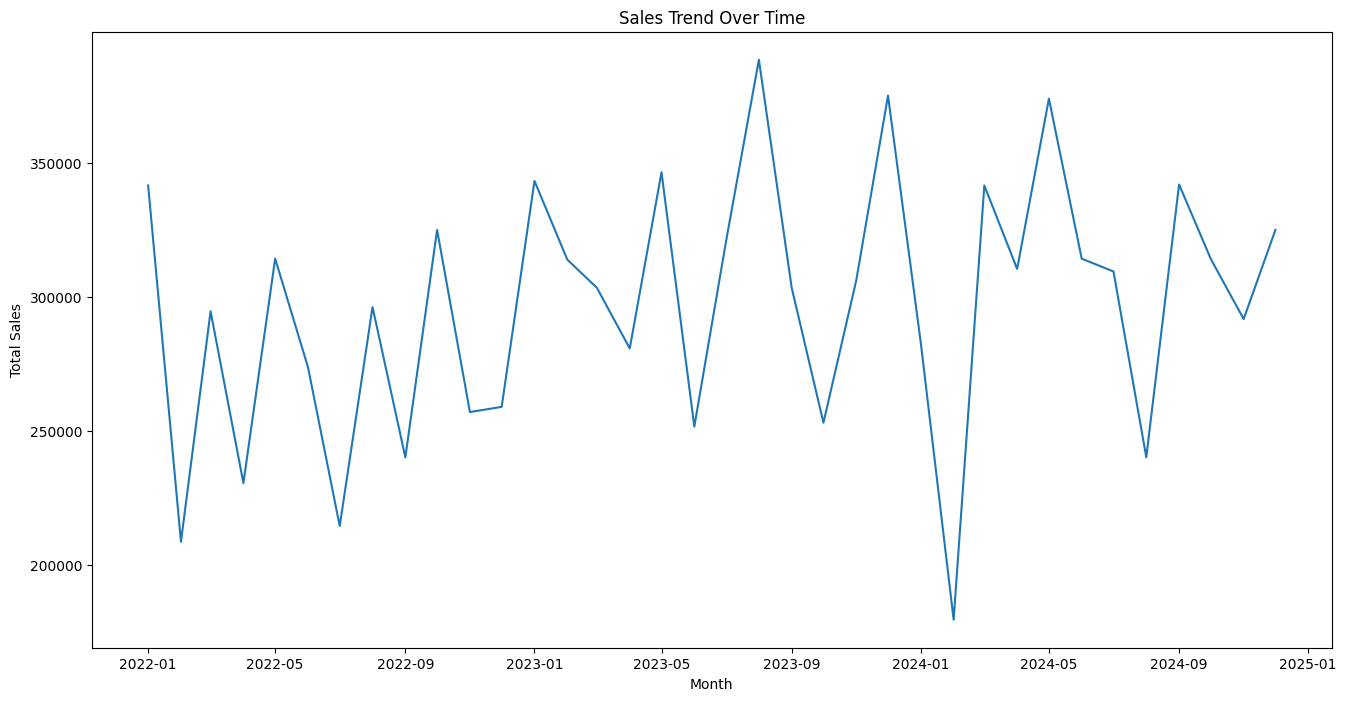

In [13]:
plt.figure(figsize=(16,8)) # Set the size of the figure
plt.plot(monthly_sales.index.to_timestamp(), monthly_sales.values) # Plot line chart using month (converted to timestamp) on X-axis and sales values on Y-axis
plt.title('Sales Trend Over Time') # Add chart title
plt.xlabel('Month') # x-axis
plt.ylabel('Total Sales') #y_axis

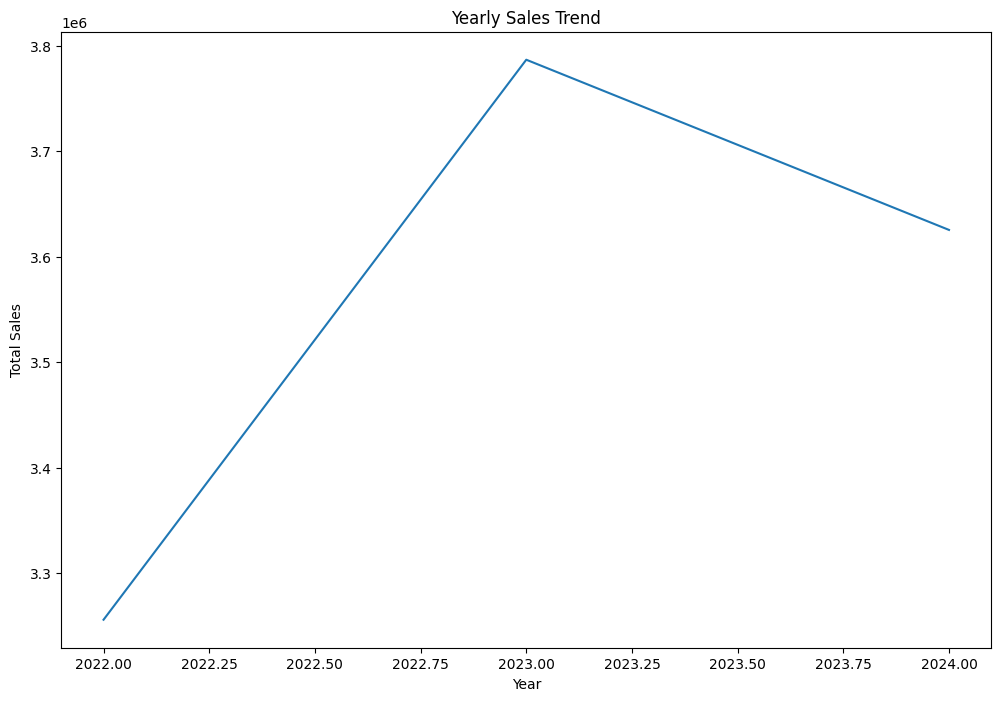

In [14]:
yearly_sales = df.groupby(df['Order Date'].dt.year)['Sales'].sum() # Plot line chart using yearly_sales index (Year) on X-axis and sales values on Y-axis

plt.figure(figsize=(12,8)) #Set the size of the plot
plt.plot(yearly_sales.index, yearly_sales.values) #create plot
plt.title('Yearly Sales Trend') #title of the plot
plt.xlabel('Year') #x-axis of the plot
plt.ylabel('Total Sales') #y-axis of the plot
plt.show() #Display the plot

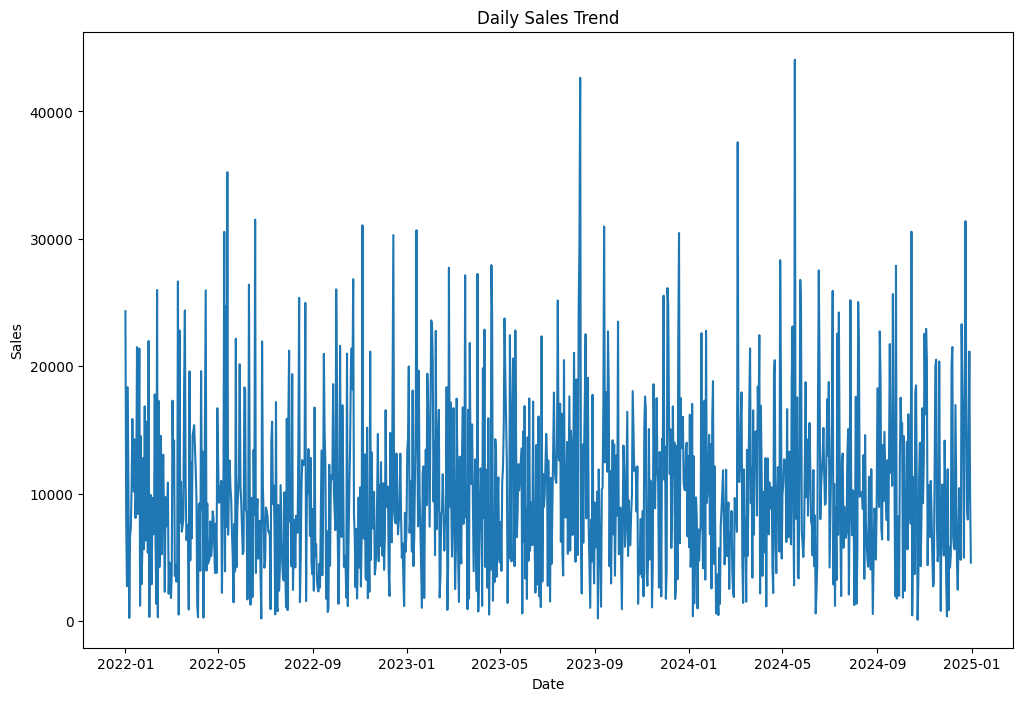

In [15]:
daily_sales = df.groupby('Order Date')['Sales'].sum() # Group data by each Order Date and calculate total Sales for each day
plt.figure(figsize=(12,8)) # Create a new figure with size 12x8 inches for better visibility
plt.plot(daily_sales.index, daily_sales.values) # Plot line chart using Date on X-axis and Sales values on Y-axis
plt.title('Daily Sales Trend') # Add chart title
plt.xlabel('Date') # Label for X-axis (Date)
plt.ylabel('Sales') # Label for Y-axis (Sales amount)
plt.show() #Display the plot

<Axes: title={'center': 'Monthly Sales & Profit Trend'}, xlabel='Month'>

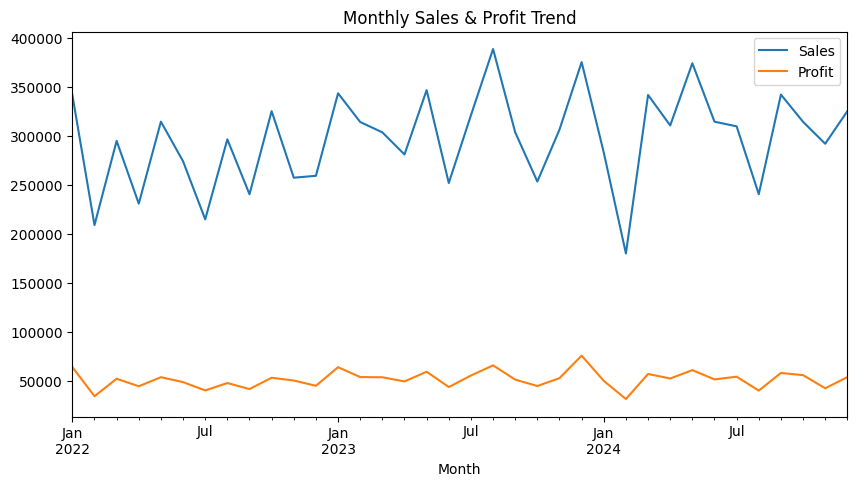

In [16]:
df['Order Date'] = pd.to_datetime(df['Order Date']) # Convert the 'Order Date' column to datetime format so that we can extract time-based features
df['Month'] = df['Order Date'].dt.to_period('M') # Create a new column 'Month' representing the year-month period of each order
monthly_sales = df.groupby('Month')[['Sales', 'Profit']].sum() # Group the data by 'Month' and sum the 'Sales' and 'Profit' for each month
monthly_sales.plot(figsize=(10,5), title='Monthly Sales & Profit Trend') # Plot the monthly sales and profit trend with a figure size of 10x5 and a title

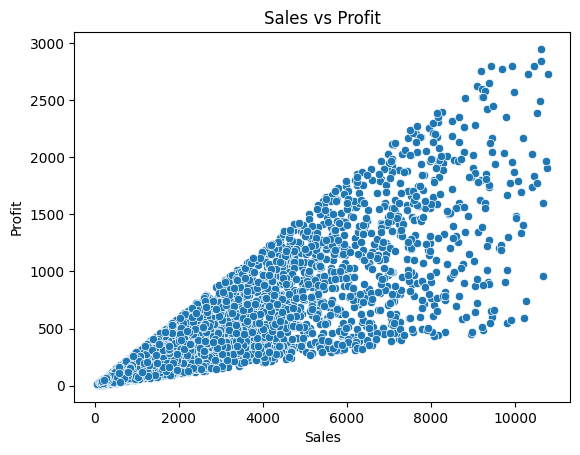

In [17]:
sns.scatterplot(x='Sales', y='Profit', data=df) # Scatter plot to see relationship between Sales and Profit
plt.title('Sales vs Profit') # Title of the plot
plt.show() #Display of the plot

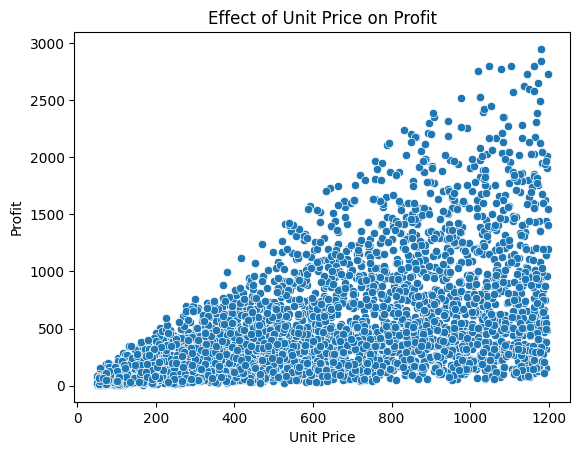

In [18]:
df['Unit Price'] = df['Sales'] / df['Quantity'] #Calculate Unit Price by Mathmatical formulla
sns.scatterplot(x='Unit Price', y='Profit', data=df) #Sactterplot to show the relattionship between Unit Price and Profit
plt.title('Effect of Unit Price on Profit') #Title of the plot
plt.xlabel('Unit Price') #x-axis of the plot
plt.ylabel('Profit') #y-axis of the plot
plt.show() #Display of the plot

In [19]:
correlation = df['Unit Price'].corr(df['Profit']) #Correlation between unit price and profit
print("Correlation between Unit Price and Profit:", correlation)

Correlation between Unit Price and Profit: 0.5451202517270884


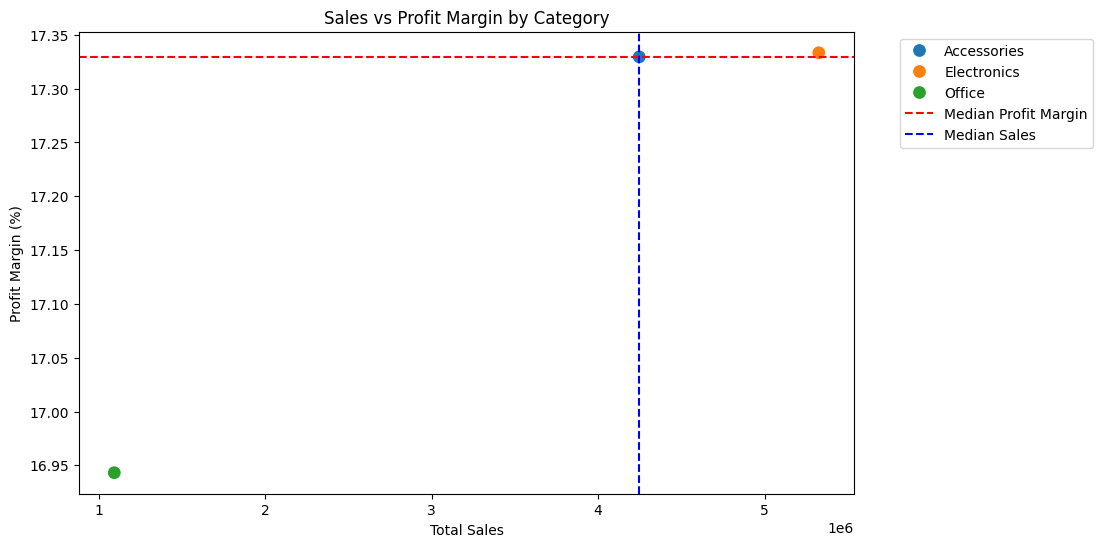

In [20]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index() # Group the data by 'Category', summing 'Sales' and 'Profit', and reset the index
category_summary['Profit Margin'] = category_summary['Profit'] / category_summary['Sales'] * 100 # Calculate profit margin for each category as a percentage
high_sales = category_summary['Sales'].median() # Find the median of total sales and profit margin
low_margin = category_summary['Profit Margin'].median()

low_profit_categories = category_summary[(category_summary['Sales'] > high_sales) &
                                         (category_summary['Profit Margin'] < low_margin)] # Identify categories with high sales but low profit margin (potentially inefficient categories)

plt.figure(figsize=(10,6)) # Set figure size for the scatter plot
sns.scatterplot(x='Sales', y='Profit Margin', data=category_summary, hue='Category', s=100) # Create a scatter plot: Sales on x-axis, Profit Margin on y-axis, colored by Category, with size 100

plt.title('Sales vs Profit Margin by Category') #Create the title of the plot
plt.xlabel('Total Sales') #x-axis of the plot
plt.ylabel('Profit Margin (%)') #y-axis of the plot
plt.axhline(low_margin, color='red', linestyle='--', label='Median Profit Margin') # Add horizontal line at median profit margin
plt.axvline(high_sales, color='blue', linestyle='--', label='Median Sales') # Add vertical line at median sales
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left') # Place legend outside the plot on the upper left
plt.show() #Display of the plot


In [21]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index() # Group the data by 'Region', summing 'Sales' and 'Profit', and reset the index to make 'Region' a column
region_summary['Profit Margin'] = region_summary['Profit'] / region_summary['Sales'] * 100 # Calculate the profit margin (%) for each region
print(region_summary) # Display the resulting summary table with Sales, Profit, and Profit Margin for each region

  Region    Sales     Profit  Profit Margin
0   East  2675110  464888.46      17.378293
1  North  2488773  426314.75      17.129515
2  South  2659548  458103.27      17.224854
3   West  2844450  495358.73      17.414921


In [22]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().reset_index() # Group the data by 'Category', summing 'Sales' and 'Profit', and reset the index
category_summary['Profit Margin'] = category_summary['Profit'] / category_summary['Sales'] * 100 # Calculate the profit margin (%) for each category
print(category_summary) # Print the summary table showing Sales, Profit, and Profit Margin for each category

      Category    Sales     Profit  Profit Margin
0  Accessories  4247591  736084.74      17.329464
1  Electronics  5326074  923185.59      17.333323
2       Office  1094216  185394.88      16.943170


<Figure size 2000x1000 with 0 Axes>

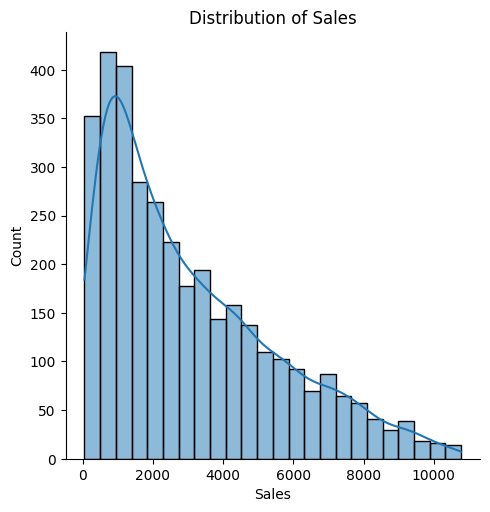

In [23]:
plt.figure(figsize=(20,10)) # Set the size of the plot
sns.displot(df['Sales'],kde=True) #Distribution plot
plt.title('Distribution of Sales') #Title of the plot
plt.show() #Display the plot

<Figure size 2000x1000 with 0 Axes>

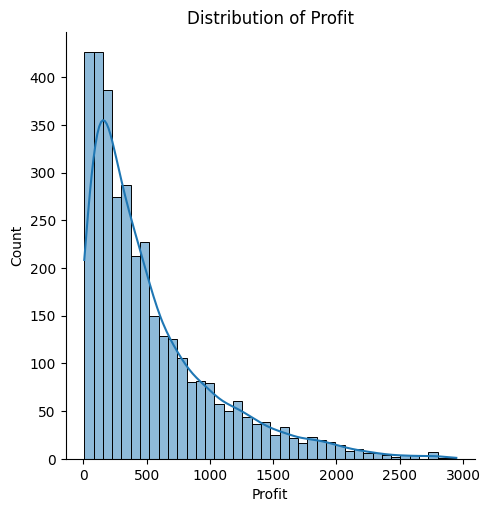

In [24]:
plt.figure(figsize=(20,10)) #Set the size of the plot
sns.displot(df['Profit'],kde=True) #Distribution plot
plt.title('Distribution of Profit') #Title plot
plt.show() #Display the plot

In [25]:
df['Date']=df['Order Date'].dt.day
df['Month']=df['Order Date'].dt.month
df['Year']=df['Order Date'].dt.year
df.drop('Order Date',axis=1, inplace=True)

In [26]:
categorical_cols = ['Product Name', 'Category', 'Region']

# Create encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform
encoded_features = ohe.fit_transform(df[categorical_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded_features,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=df.index
)

# Merge back to original dataframe
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)

In [27]:
x=df.drop(['Profit'], axis=1) #Independent Variables, dropping date-time columns
y=df['Profit'] #Target variable

In [28]:
categorical_cols = x.select_dtypes(include=['object']).columns
numerical_cols = x.select_dtypes(include=['int64','float64']).columns

In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [30]:
StandardScaler=StandardScaler()


In [31]:
scores=[] #Initialize an empty list to store R-squared scores for different random states
for i in range(1000): #Loop through 1000 different random states to find the best train-test split
  x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=i)   # random_state=i ensures a different split in each iteration
  lr=LinearRegression() # inintiallize linear regression
  pipe=make_pipeline(preprocessor,lr) #  # Create a pipeline: first apply column transformations, then train the model
  pipe.fit(x_train,y_train)    # Fit the pipeline on the training data
  y_predict=pipe.predict(x_test)   # predict x-test with pipline
  scores.append(r2_score(y_test,y_predict))   # Calculate R-squared score and append it to the scores list

In [32]:
np.argmax(scores) # Find the index of the maximum R-squared score in the scores list

np.int64(893)

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=np.argmax(scores))# random_state is set using np.argmax(scores) to ensure reproducibility
lr=LinearRegression() #iniatilize linearregression model
pipe=make_pipeline(lr) #making pipeline
pipe.fit(x_train,y_train) #fit the pipeline on training data
y_predict=pipe.predict(x_test) # predict the target value for the test data
(r2_score(y_test,y_predict)) # calculate r-squared score

0.7414629177506844